In [1]:
import os

os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"
import numpy as np
import pandas as pd
import pydicom
import random
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import KFold




In [2]:
import tensorflow as tf
import tensorflow.keras.backend as K
import tensorflow.keras.layers as L
import tensorflow.keras.models as M




2026-05-02 22:51:45.537732: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-02 22:51:45.557756: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777762305.579837      11 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777762305.586410      11 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-02 22:51:45.608973: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [3]:
def seed_everything(seed=2020):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    return seed




In [4]:
ROOT = "../input/osic-pulmonary-fibrosis-progression"

tr = pd.read_csv(f"{ROOT}/train.csv")
tr.drop_duplicates(keep=False, inplace=True, subset=["Patient", "Weeks"])
chunk = pd.read_csv(f"{ROOT}/test.csv")

print("add infos")
sub = pd.read_csv(f"{ROOT}/sample_submission.csv")
sub["Patient"] = sub["Patient_Week"].apply(lambda x: x.split("_")[0])
sub["Weeks"] = sub["Patient_Week"].apply(lambda x: int(x.split("_")[-1]))
sub = sub[["Patient", "Weeks", "Confidence", "Patient_Week"]]
sub = sub.merge(chunk.drop("Weeks", axis=1), on="Patient", how="left")




add infos


In [5]:
tr["WHERE"] = "train"
chunk["WHERE"] = "val"
sub["WHERE"] = "test"
data = pd.concat([tr, chunk, sub], ignore_index=True)




In [6]:
print(tr.shape, chunk.shape, sub.shape, data.shape)
print(
    tr.Patient.nunique(),
    chunk.Patient.nunique(),
    sub.Patient.nunique(),
    data.Patient.nunique(),
)




(1380, 8) (18, 8) (1908, 10) (3306, 10)
158 18 18 176


In [7]:
data["min_week"] = data["Weeks"]
data.loc[data.WHERE == "test", "min_week"] = np.nan
data["min_week"] = data.groupby("Patient")["min_week"].transform("min")




In [8]:
base = data.loc[data.Weeks == data.min_week]
base = base[["Patient", "FVC"]].copy()
base.columns = ["Patient", "min_FVC"]
base["nb"] = 1
base["nb"] = base.groupby("Patient")["nb"].transform("cumsum")
base = base[base.nb == 1]
base.drop("nb", axis=1, inplace=True)




In [9]:
data = data.merge(base, on="Patient", how="left")
data["base_week"] = data["Weeks"] - data["min_week"]
del base




In [10]:
COLS = ["Sex", "SmokingStatus"]
FE = []
for col in COLS:
    for mod in data[col].unique():
        FE.append(mod)
        data[mod] = (data[col] == mod).astype(int)




In [11]:
data["age"] = (data["Age"] - data["Age"].min()) / (
    data["Age"].max() - data["Age"].min()
)
data["BASE"] = (data["min_FVC"] - data["min_FVC"].min()) / (
    data["min_FVC"].max() - data["min_FVC"].min()
)
data["week"] = (data["base_week"] - data["base_week"].min()) / (
    data["base_week"].max() - data["base_week"].min()
)
data["percent"] = (data["Percent"] - data["Percent"].min()) / (
    data["Percent"].max() - data["Percent"].min()
)
FE += ["age", "percent", "week", "BASE"]




In [12]:
tr = data.loc[data.WHERE == "train"]
chunk = data.loc[data.WHERE == "val"]
sub = data.loc[data.WHERE == "test"]
del data




In [13]:
tr.to_csv("tr.csv", index=False)
chunk.to_csv("chunk.csv", index=False)
sub.to_csv("sub.csv", index=False)




In [14]:
SEED = seed_everything(42)
NFOLD = 5
EPOCHS = 800
BATCH_SIZE = 128

M_LOSS = 0.775
LR = 0.01  # learning rate for Adagrad
DECAY = 0.01

kf = KFold(n_splits=NFOLD)




In [15]:
C1, C2 = tf.constant(70, dtype="float32"), tf.constant(1000, dtype="float32")


def score(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_true = tf.expand_dims(y_true, -1)  # shape (batch, 1)

    sigma = y_pred[:, 2] - y_pred[:, 0]
    fvc_pred = y_pred[:, 1]

    sigma_clip = tf.maximum(sigma, C1)
    delta = tf.abs(y_true[:, 0] - fvc_pred)
    delta = tf.minimum(delta, C2)
    sq2 = tf.sqrt(tf.constant(2.0, dtype=tf.float32))
    metric = (delta / sigma_clip) * sq2 + tf.math.log(sigma_clip * sq2)
    return -K.mean(metric)


def qloss(y_true, y_pred):
    # expand y_true to (batch, 1) so broadcasting works with (batch, 3)
    y_true = tf.cast(y_true, tf.float32)
    y_true = tf.expand_dims(y_true, -1)
    qs = [0.2, 0.5, 0.8]
    q = tf.constant(np.array([qs]), dtype=tf.float32)
    e = y_true - y_pred
    v = tf.maximum(q * e, (q - 1) * e)
    return K.mean(v)


def mloss(_lambda):
    def loss(y_true, y_pred):
        return _lambda * qloss(y_true, y_pred) + (1 - _lambda) * score(y_true, y_pred)

    return loss


def make_model():
    z = L.Input((len(FE),), name="Patient")
    x = L.Dense(120, activation="relu", name="d1")(z)
    x = L.Dense(120, activation="relu", name="d2")(x)
    p1 = L.Dense(3, activation="linear", name="p1")(x)  # linear outputs
    p2 = L.Dense(3, activation="relu", name="p2")(x)
    preds = L.Lambda(lambda x: x[0] + tf.cumsum(x[1], axis=1), name="preds")([p1, p2])

    model = M.Model(z, preds, name="ANN")
    model.compile(
        loss=mloss(0.2),  # give more weight to the Laplace score loss
        optimizer=tf.keras.optimizers.Adagrad(learning_rate=LR),
        metrics=[score],
    )
    return model




2026-05-02 22:51:57.293292: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [16]:
net = make_model()
print(net.summary())
print(net.count_params())




Model: "ANN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Patient             │ (None, 9)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ d1 (Dense)          │ (None, 120)       │      1,200 │ Patient[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ d2 (Dense)          │ (None, 120)       │     14,520 │ d1[0][0]          │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ p1 (Dense)          │ (None, 3)         │        363 │ d2[0][0]          │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ p2 (Dense)          │ (None, 3)         │        363 │ d2[0][0]          │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ preds (Lambda)      │ (None, 3)         │          0 │ p1[0][0],         │
│                     │                   │            │ p2[0][0]          │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 16,446 (64.24 KB)

 Trainable params: 16,446 (64.24 KB)

 Non-trainable params: 0 (0.00 B)

None
16446


In [17]:
tr[FE].columns




Index(['Male', 'Female', 'Never smoked', 'Ex-smoker', 'Currently smokes',
       'age', 'percent', 'week', 'BASE'],
      dtype='object')

In [18]:
y = tr["FVC"].values
z = tr[FE].values
ze = sub[FE].values
pe = np.zeros((ze.shape[0], 3))
pred = np.zeros((z.shape[0], 3))
delta = np.zeros((z.shape[0], 3))




In [19]:
cnt = 0
train = []
val = []

for tr_idx, val_idx in kf.split(z):
    cnt += 1
    print(f"FOLD {cnt}")

    net = make_model()

    net.fit(
        z[tr_idx],
        y[tr_idx],
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        validation_data=(z[val_idx], y[val_idx]),
        verbose=0,
    )

    print("train", net.evaluate(z[tr_idx], y[tr_idx], verbose=0, batch_size=BATCH_SIZE))
    print("val", net.evaluate(z[val_idx], y[val_idx], verbose=0, batch_size=BATCH_SIZE))
    pred[val_idx] = net.predict(z[val_idx], batch_size=BATCH_SIZE, verbose=0)
    print()
    pe += net.predict(ze, batch_size=BATCH_SIZE, verbose=0) / NFOLD

    delta += net.predict(z) / NFOLD




FOLD 1
train [5.011334419250488, -6.610179424285889]
val [9.255859375, -6.875146389007568]

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 600us/step
FOLD 2
train [5.7928314208984375, -6.696378707885742]
val [6.428510665893555, -6.694523334503174]

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 667us/step
FOLD 3
train [6.781283378601074, -7.308329105377197]
val [6.5738935470581055, -7.390176296234131]

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
FOLD 4
train [5.706327438354492, -6.691156387329102]
val [5.063024520874023, -6.607224941253662]

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 646us/step
FOLD 5
train [6.252981662750244, -7.1159820556640625]
val [7.562089443206787, -7.088290691375732]

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 797us/step


In [20]:
sigma_opt = mean_absolute_error(y, pred[:, 1])
unc = pred[:, 2] - pred[:, 0]
sigma_mean = np.mean(unc)
print(sigma_opt, sigma_mean)




148.86097009631172 203.56925079787987


In [21]:
o_clipped = np.maximum(delta[:, 2] - delta[:, 0], 70)
delta_err = np.minimum(np.abs(delta[:, 1] - y), 1000)
sqrt = np.sqrt(2.0)
score_vals = (-(sqrt * (delta_err)) / (o_clipped)) - np.log(sqrt * o_clipped)

logL_Score = np.mean(score_vals)




In [22]:
print(
    "we are using fix seed value always to avoid RANDOMIZATION (NEED TO GET SAME RESULT)"
)
print("Seed value          =", SEED)
print("Number of folds     =", NFOLD)
print("Number of epochs    =", EPOCHS)

print("\nmean_absolute_error =", sigma_opt)

print("unc_mean            =", unc.mean())
print()
print("Log_laplace_Scores  =", logL_Score)
print()
print("unc_min             =", unc.min())
print("unc_max             =", unc.max())
print("unc_mean            =", (unc >= 0).mean())




we are using fix seed value always to avoid RANDOMIZATION (NEED TO GET SAME RESULT)
Seed value          = 42
Number of folds     = 5
Number of epochs    = 800

mean_absolute_error = 148.86097009631172
unc_mean            = 203.56925079787987

Log_laplace_Scores  = -6.612189138046868

unc_min             = 60.7435302734375
unc_max             = 418.442626953125
unc_mean            = 1.0


In [23]:
stats = pd.DataFrame()
index = 0




In [24]:
data_row = [
    [
        index,
        logL_Score,
        sigma_opt,
        unc.mean(),
        unc.min(),
        unc.max(),
        (unc >= 0).mean(),
        BATCH_SIZE,
        EPOCHS,
        NFOLD,
        M_LOSS,
        LR,
        DECAY,
        SEED,
    ]
]
columns = [
    "S.No",
    "Score",
    "meanAbseErr",
    "unc.mean",
    "unc.min",
    "unc.max",
    "(unc>=0)",
    "Bsize",
    "epoch",
    "NFOLD",
    "M_LOSS",
    "LR",
    "DECAY",
    "seed",
]
kernal_stats = pd.DataFrame(data_row, columns=columns)
stats = pd.concat([stats, kernal_stats], ignore_index=True)
stats.to_csv("kernal.csv", index=False)
index += 1
stats




,S.No,Score,meanAbseErr,unc.mean,unc.min,unc.max,(unc>=0),Bsize,epoch,NFOLD,M_LOSS,LR,DECAY,seed
0,0,-6.612189,148.86097,203.569251,60.74353,418.442627,1.0,128,800,5,0.775,0.01,0.01,42


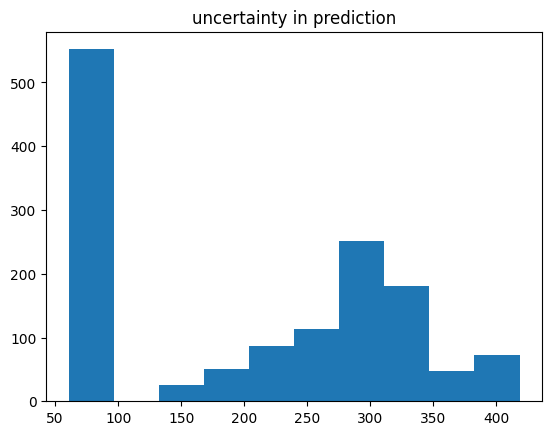

In [25]:
plt.hist(unc)
plt.title("uncertainty in prediction")
plt.show()




/tmp/ipykernel_11/2737089080.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(unc)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


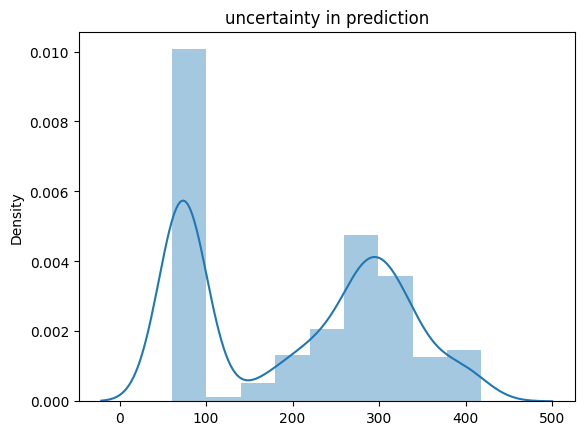

In [26]:
import seaborn as sns

sns.distplot(unc)
plt.title("uncertainty in prediction")
plt.show()




In [27]:
sub["FVC1"] = pe[:, 1]
sub["Confidence1"] = pe[:, 2] - pe[:, 0]




In [28]:
subm = sub[["Patient_Week", "FVC", "Confidence", "FVC1", "Confidence1"]].copy()




In [29]:
subm.loc[~subm.FVC1.isnull(), "FVC"] = subm.loc[~subm.FVC1.isnull(), "FVC1"]

subm["Confidence"] = np.where(
    subm["Confidence1"].notnull(),
    subm["Confidence1"],
    subm["Confidence"],
)
subm["Confidence"] = subm["Confidence"].clip(lower=70)

if sigma_mean < 70:
    subm["Confidence"] = 70




/tmp/ipykernel_11/1898664330.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[2212.38482666 2210.76113892 2209.13787842 ... 3144.83428955 3142.87164307
 3140.90930176]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  subm.loc[~subm.FVC1.isnull(), "FVC"] = subm.loc[~subm.FVC1.isnull(), "FVC1"]


In [30]:
otest = pd.read_csv("../input/osic-pulmonary-fibrosis-progression/test.csv")
for i in range(len(otest)):
    subm.loc[
        subm["Patient_Week"] == otest.Patient[i] + "_" + str(otest.Weeks[i]), "FVC"
    ] = otest.FVC[i]
    subm.loc[
        subm["Patient_Week"] == otest.Patient[i] + "_" + str(otest.Weeks[i]),
        "Confidence",
    ] = 100




In [31]:
# Remove any rows that still have missing identifiers before saving
subm = subm.dropna(subset=["Patient_Week"])
subm = subm[
    subm["Patient_Week"].notna()
]  # extra safety for NaN strings after conversion
subm["Patient_Week"] = subm["Patient_Week"].astype(str)
subm = subm[subm["Patient_Week"].str.strip().ne("")].copy()

subm[["FVC", "Confidence"]] = subm[["FVC", "Confidence"]].astype(float)
subm[["Patient_Week", "FVC", "Confidence"]].to_csv("submission.csv", index=False)




In [32]:
subm

,Patient_Week,FVC,Confidence,FVC1,Confidence1
1398,ID00126637202218610655908_-3,2212.384827,191.335571,2212.384827,191.335571
1399,ID00126637202218610655908_-2,2210.761139,191.464996,2210.761139,191.464996
1400,ID00126637202218610655908_-1,2209.137878,191.594543,2209.137878,191.594543
1401,ID00126637202218610655908_0,2207.514221,191.723724,2207.514221,191.723724
1402,ID00126637202218610655908_1,2205.910980,191.853394,2205.910980,191.853394
...,...,...,...,...,...
3301,ID00047637202184938901501_98,3148.759216,242.321228,3148.759216,242.321228
3302,ID00047637202184938901501_99,3146.797180,242.460144,3146.797180,242.460144
3303,ID00047637202184938901501_100,3144.834290,242.598633,3144.834290,242.598633
3304,ID00047637202184938901501_101,3142.871643,242.737244,3142.871643,242.737244
